# What Makes a Book a 5-Star Read?
## Analiza danych z Goodreads — Books Dataset, May 2024

**Dane:** [kaggle.com/datasets/dk123891/books-dataset-goodreadsmay-2024](https://www.kaggle.com/datasets/dk123891/books-dataset-goodreadsmay-2024)

**Pytania badawcze:**
1. Ktore gatunki maja najwyzsze srednie oceny?
2. Czy liczba stron wplywa na ocene?
3. Czy popularnosc (liczba ocen) koreluje z jakoscia?
4. Ktore ksiazki sa najwyzej i najnizej oceniane?

---

## 0. Importy i ustawienia

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

C1 = '#2E4057'   # granat
C2 = '#048A81'   # zielony
C3 = '#E76F51'   # pomaranczowy
C4 = '#8ECAE6'   # jasny niebieski

---
## 1. Wczytanie danych

In [6]:
# Wczytanie danych z Google Drive
df = pd.read_csv('/content/drive/MyDrive/Projekty osobiste/Projekt - Książki/data_books/Book_Details.csv')

print(f'Liczba rekordow: {len(df):,}')
print(f'Liczba kolumn:   {df.shape[1]}')
print()
print('Kolumny:')
print(df.dtypes)

Liczba rekordow: 16,225
Liczba kolumn:   15

Kolumny:
Unnamed: 0               int64
book_id                  int64
cover_image_uri         object
book_title              object
book_details            object
format                  object
publication_info        object
authorlink              object
author                  object
num_pages               object
genres                  object
num_ratings              int64
num_reviews              int64
average_rating         float64
rating_distribution     object
dtype: object


In [7]:
df.head(3)

,Unnamed: 0,book_id,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,genres,num_ratings,num_reviews,average_rating,rating_distribution
0,0,1,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Half-Blood Prince,"It is the middle of the summer, but there is a...","['652 pages, Paperback']","['First published July 16, 2005']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['652'],"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",3292516,58398,4.58,"{'5': '2,244,154', '4': '775,028', '3': '219,8..."
1,1,2,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Order of the Phoenix,Harry Potter is about to start his fifth year ...,"['912 pages, Paperback']","['First published June 21, 2003']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['912'],"['Young Adult', 'Fiction', 'Magic', 'Childrens...",3401709,64300,4.50,"{'5': '2,178,760', '4': '856,178', '3': '293,2..."
2,2,3,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Sorcerer's Stone,Harry Potter has no idea how famous he is. Tha...,"['309 pages, Hardcover']","['First published June 26, 1997']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['309'],"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",10116247,163493,4.47,"{'5': '6,544,542', '4': '2,348,390', '3': '856..."


In [8]:
# Brakujace wartosci
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Brakujace': miss, 'Procent %': miss_pct})
miss_df[miss_df['Brakujace'] > 0].sort_values('Procent %', ascending=False)

,Brakujace,Procent %
book_details,48,0.3


---
## 2. Czyszczenie danych

> **Wazne:** Po uruchomieniu komorki `df.dtypes` sprawdz dokladne nazwy kolumn i zaktualizuj stale ponizej.

In [9]:
# NAZWY KOLUMN
COL_TITLE  = 'book_title'
COL_AUTHOR = 'author'
COL_RATING = 'average_rating'
COL_COUNT  = 'num_ratings'
COL_PAGES  = 'num_pages'
COL_GENRE  = 'genres'


In [10]:
# Usuniecie duplikatow
print(f'Duplikaty: {df.duplicated().sum()}')
df = df.drop_duplicates()

# Ujednolicenie nazw kolumn (spacje - podkreslniki, male litery)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Kolumny:', df.columns.tolist())

Duplikaty: 0
Kolumny: ['unnamed:_0', 'book_id', 'cover_image_uri', 'book_title', 'book_details', 'format', 'publication_info', 'authorlink', 'author', 'num_pages', 'genres', 'num_ratings', 'num_reviews', 'average_rating', 'rating_distribution']


In [11]:
# Konwersja oceny i liczby ocen
df[COL_RATING] = pd.to_numeric(df[COL_RATING], errors='coerce')
df[COL_COUNT]  = pd.to_numeric(df[COL_COUNT],  errors='coerce')

# Liczba stron — dane w formacie "['312']" (lista jako string)
def parse_pages(val):
    try:
        return int(str(val).strip("[]' "))
    except:
        return np.nan

df[COL_PAGES] = df[COL_PAGES].apply(parse_pages)

# Usuniecie blednych ocen
n_przed = len(df)
df = df[(df[COL_RATING] > 0) & (df[COL_RATING] <= 5)]
print(f'Usunieto {n_przed - len(df)} rekordow z nieprawidlowa ocena')
print(f'Rekordow po czyszczeniu: {len(df):,}')

Usunieto 12 rekordow z nieprawidlowa ocena
Rekordow po czyszczeniu: 16,213


In [12]:
# Wyodrebnienie pierwszego gatunku
# Format w danych: "['Fiction', 'Fantasy']" lub "Fiction, Fantasy"
def first_genre(val):
    if pd.isna(val):
        return 'Unknown'
    cleaned = str(val).strip("[]'\" ").split(',')[0].strip("'\" ")
    return cleaned if cleaned else 'Unknown'

df['main_genre'] = df[COL_GENRE].apply(first_genre)

print('Top 10 gatunkow:')
print(df['main_genre'].value_counts().head(10))

Top 10 gatunkow:
main_genre
Fiction               3175
Fantasy               2234
Nonfiction            1022
Young Adult            896
Historical Fiction     790
Romance                767
Mystery                736
Science Fiction        653
Horror                 600
Classics               525
Name: count, dtype: int64


In [13]:
# Podzbior z poprawnymi danymi o stronach
df_pages = df[(df[COL_PAGES] > 0) & (df[COL_PAGES] < 5000)].copy()

# Kategorie dlugosci ksiazki
bins   = [0, 150, 300, 500, 800, 5000]
labels = ['< 150', '150-300', '300-500', '500-800', '800+']
df_pages['pages_cat'] = pd.cut(df_pages[COL_PAGES], bins=bins, labels=labels)

print(f'Rekordow z danymi o stronach: {len(df_pages):,}')

Rekordow z danymi o stronach: 15,932


---
## 3. Przeglad danych

In [14]:
df[[COL_RATING, COL_COUNT, COL_PAGES]].describe().round(2)

,average_rating,num_ratings,num_pages
count,16213.00,16213.00,15937.00
mean,4.01,85848.02,362.28
std,0.32,320361.32,254.76
min,1.00,1.00,1.00
25%,3.83,2967.00,241.00
50%,4.03,16293.00,328.00
75%,4.21,55976.00,426.00
max,5.00,10116247.00,8258.00


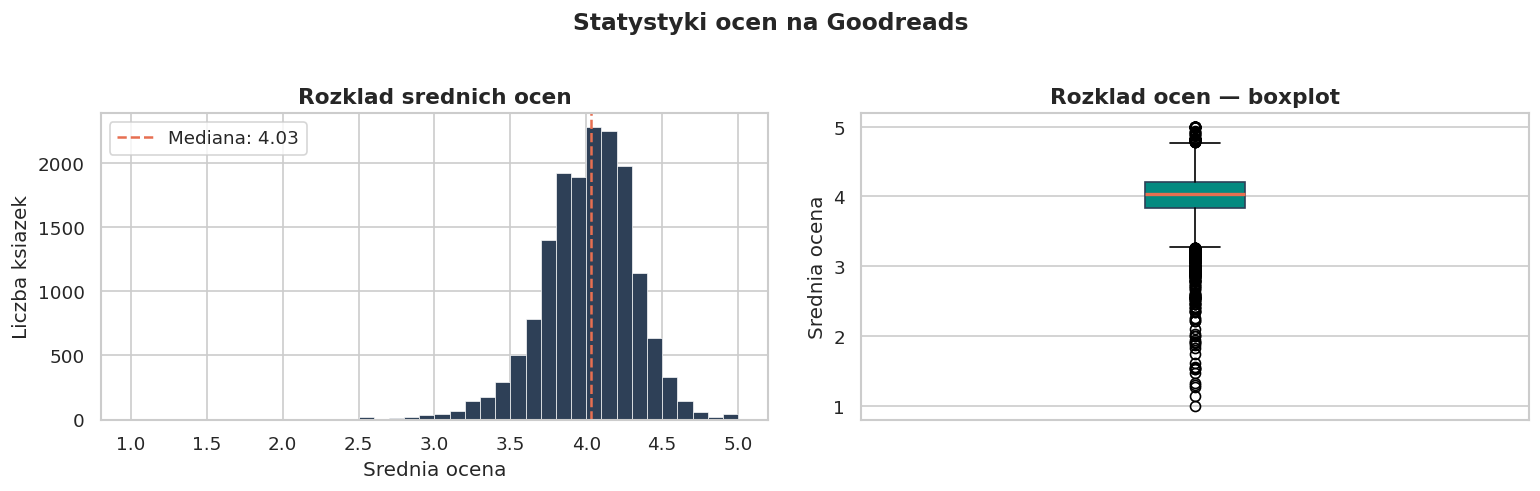

Srednia:   4.005
Mediana:   4.030
Odch.std:  0.318


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram ocen
axes[0].hist(df[COL_RATING].dropna(), bins=40, color=C1, edgecolor='white', linewidth=0.4)
axes[0].axvline(df[COL_RATING].median(), color=C3, linestyle='--', linewidth=1.5,
                label=f"Mediana: {df[COL_RATING].median():.2f}")
axes[0].set_title('Rozklad srednich ocen', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Srednia ocena')
axes[0].set_ylabel('Liczba ksiazek')
axes[0].legend()

# Boxplot
axes[1].boxplot(df[COL_RATING].dropna(), patch_artist=True,
                boxprops=dict(facecolor=C2, color=C1),
                medianprops=dict(color=C3, linewidth=2))
axes[1].set_title('Rozklad ocen — boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Srednia ocena')
axes[1].set_xticks([])

plt.suptitle('Statystyki ocen na Goodreads', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Srednia:   {df[COL_RATING].mean():.3f}")
print(f"Mediana:   {df[COL_RATING].median():.3f}")
print(f"Odch.std:  {df[COL_RATING].std():.3f}")

### Wniosek
Rozkład ocen jest lewoskośny, co oznacza, że większość książek otrzymuje wysokie oceny. Histogram wyraźnie pokazuje koncentrację książek w przedziale 3.5-4.5. Mediana (4.03) jest nieco wyższa niż średnia (4.01), co potwierdza, że więcej ocen koncentruje się w górnej części skali. Boxplot uwidacznia, że 75% książek ma średnią ocenę powyżej 3.83, a 50% powyżej 4.03, co wskazuje na ogólnie pozytywne oceny na platformie Goodreads.

---
## 4. Gatunki vs oceny

In [16]:
# Srednia ocena per gatunek (min. 30 ksiazek)
genre_stats = (
    df.groupby('main_genre')[COL_RATING]
    .agg(srednia='mean', liczba='count', odch_std='std')
    .query('liczba >= 30')
    .sort_values('srednia', ascending=False)
    .head(15)
)

print(genre_stats.round(3).to_string())

                    srednia  liczba  odch_std
main_genre                                   
Manga                 4.297     117     0.207
Christian             4.266      86     0.227
Poetry                4.219     225     0.259
Paranormal Romance    4.206      75     0.184
Unknown               4.204     313     0.626
Contemporary          4.186      49     0.194
Picture Books         4.183     120     0.210
Christian Fiction     4.181      58     0.204
Middle Grade          4.171      39     0.170
Graphic Novels        4.155     128     0.281
Spirituality          4.137      82     0.235
Science               4.130      87     0.188
Comics                4.125      98     0.365
Childrens             4.119     141     0.200
Paranormal            4.114      82     0.230


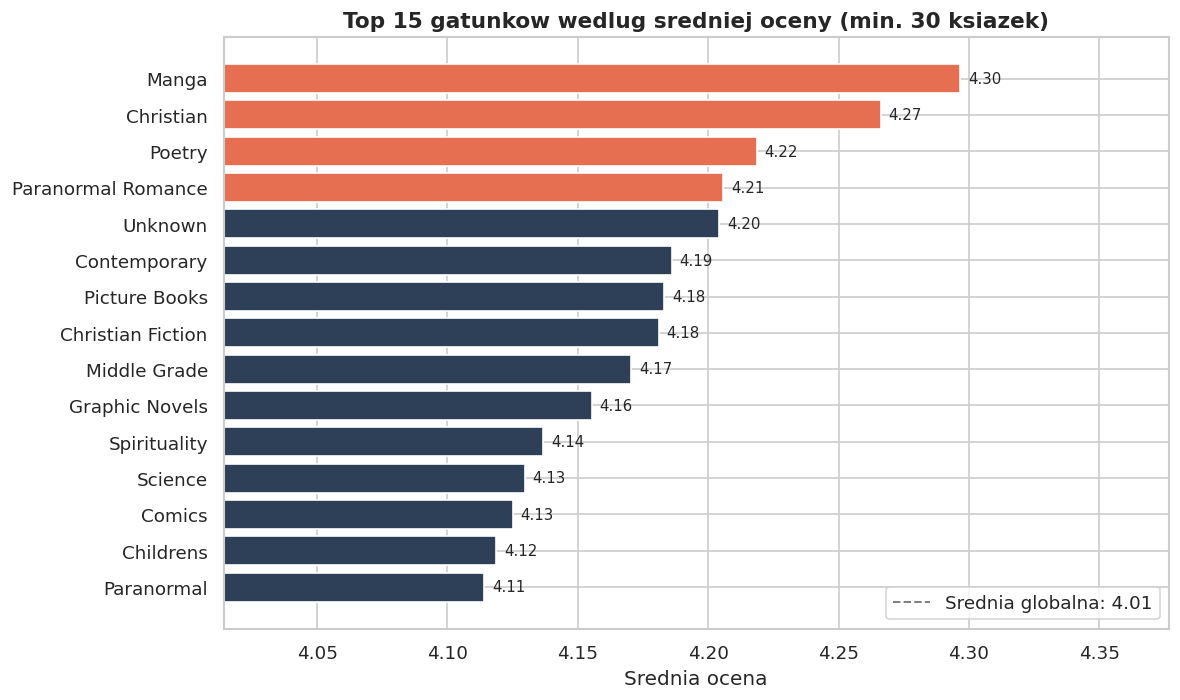

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

q75 = genre_stats['srednia'].quantile(0.75)
kolory = [C3 if v >= q75 else C1 for v in genre_stats['srednia']]

bars = ax.barh(
    genre_stats.index[::-1],
    genre_stats['srednia'][::-1],
    color=kolory[::-1],
    edgecolor='white'
)

for bar, val in zip(bars, genre_stats['srednia'][::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9)

srednia_glob = df[COL_RATING].mean()
ax.axvline(srednia_glob, color='gray', linestyle='--', linewidth=1.2,
           label=f'Srednia globalna: {srednia_glob:.2f}')

ax.set_xlim(genre_stats['srednia'].min() - 0.1, genre_stats['srednia'].max() + 0.08)
ax.set_title('Top 15 gatunkow wedlug sredniej oceny (min. 30 ksiazek)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Srednia ocena')
ax.legend()

plt.tight_layout()
plt.show()

### Wniosek
Gatunki takie jak Manga, Christian i Poetry mają najwyższe średnie oceny, znacznie przekraczając średnią globalną (4.01). Wiele z tych gatunków to nisze, co sugeruje, że ich czytelnicy są bardziej selektywni lub mają wyższe zadowolenie z wybranych tytułów. Warto zauważyć, że 'Unknown' również ma wysoką średnią, co może wynikać z błędów w kategoryzacji lub braku dominującego gatunku dla tych tytułów. Wykres słupkowy jasno pokazuje, które gatunki plasują się powyżej (zaznaczone pomarańczowym kolorem) i poniżej 75. percentyla średnich ocen gatunków.

---
## 5. Liczba stron vs ocena

In [18]:
corr_pages = df_pages[COL_PAGES].corr(df_pages[COL_RATING])
print(f'Korelacja Pearsona (strony vs ocena): {corr_pages:.4f}')
print()
print('Srednia ocena wedlug dlugosci ksiazki:')
print(
    df_pages.groupby('pages_cat', observed=True)[COL_RATING].agg(srednia='mean', liczba='count').round(3)
)

Korelacja Pearsona (strony vs ocena): 0.1889

Srednia ocena wedlug dlugosci ksiazki:
           srednia  liczba
pages_cat                 
< 150        4.020    1436
150-300      3.943    4994
300-500      4.000    7129
500-800      4.102    1859
800+         4.258     514


/tmp/ipykernel_17588/3819101900.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(dane_per_kat, patch_artist=True, labels=labels)


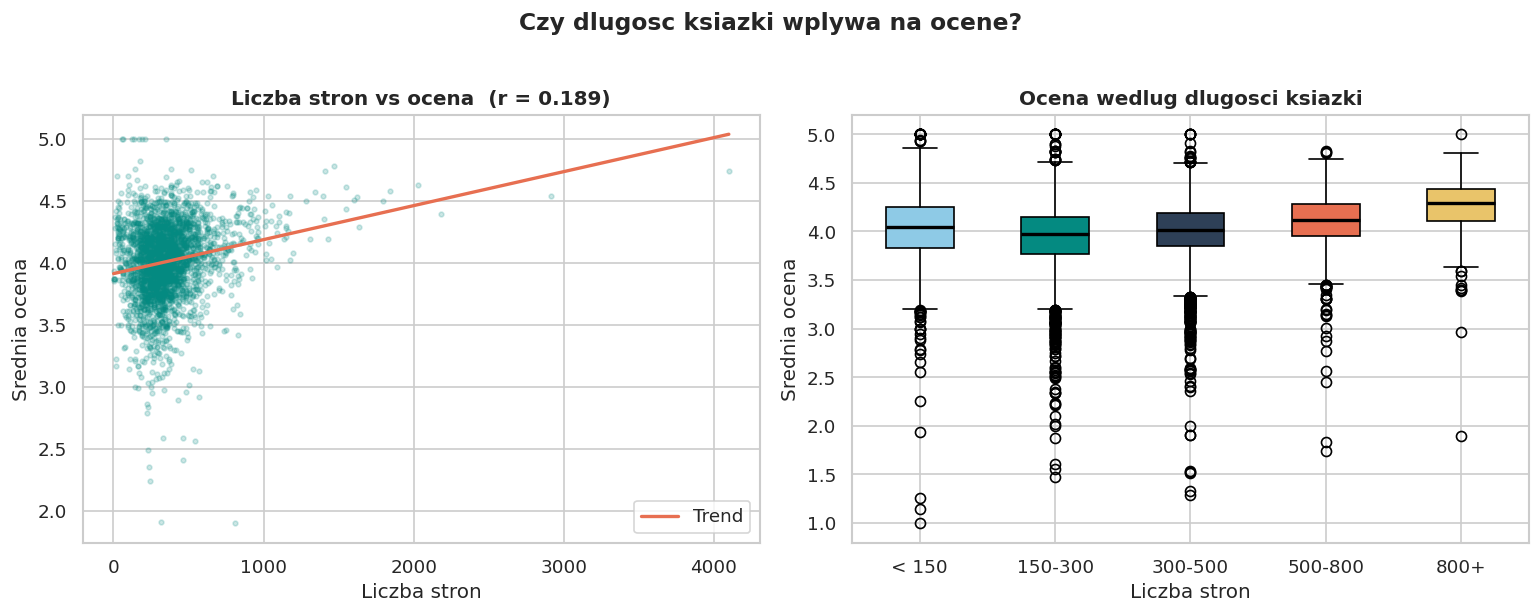

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter — probka 3000 punktow dla czytelnosci
sample = df_pages.dropna(subset=[COL_PAGES, COL_RATING]).sample(
    n=min(3000, len(df_pages)), random_state=42
)

axes[0].scatter(sample[COL_PAGES], sample[COL_RATING], alpha=0.2, s=8, color=C2)

z = np.polyfit(sample[COL_PAGES], sample[COL_RATING], 1)
xs = np.linspace(sample[COL_PAGES].min(), sample[COL_PAGES].max(), 200)
axes[0].plot(xs, np.poly1d(z)(xs), color=C3, linewidth=2, label='Trend')

axes[0].set_title(f'Liczba stron vs ocena  (r = {corr_pages:.3f})',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Liczba stron')
axes[0].set_ylabel('Srednia ocena')
axes[0].legend()

# Boxplot per kategoria stron
dane_per_kat = [
    df_pages[df_pages['pages_cat'] == kat][COL_RATING].dropna()
    for kat in labels
]

bp = axes[1].boxplot(dane_per_kat, patch_artist=True, labels=labels)
for patch, kolor in zip(bp['boxes'], [C4, C2, C1, C3, '#E9C46A']):
    patch.set_facecolor(kolor)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

axes[1].set_title('Ocena wedlug dlugosci ksiazki', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Liczba stron')
axes[1].set_ylabel('Srednia ocena')

plt.suptitle('Czy dlugosc ksiazki wplywa na ocene?', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Wniosek
Korelacja między liczbą stron a średnią oceną jest bardzo niska (r = 0.189), co wskazuje, że długość książki ma znikomy wpływ na to, jak jest oceniana. Wykres rozrzutu pokazuje szeroki rozrzut punktów, co potwierdza brak silnej zależności, choć linia trendu wskazuje na bardzo delikatny wzrost oceny wraz z długością. Boxploty dla poszczególnych kategorii długości książek pokazują, że mediany ocen są dość zbliżone, jednak najdłuższe książki (800+) wykazują nieznacznie wyższe średnie i mediany ocen, co może sugerować, że bardzo długie książki są lepiej oceniane przez swoich czytelników.

---
## 6. Popularnosc vs ocena

In [20]:
sample2 = df.dropna(subset=[COL_COUNT, COL_RATING]).sample(
    n=min(3000, len(df)), random_state=42
)

log_count = np.log10(sample2[COL_COUNT].clip(lower=1))
corr_pop  = log_count.corr(sample2[COL_RATING])

print(f'Korelacja log(liczba ocen) vs srednia ocena: {corr_pop:.4f}')

Korelacja log(liczba ocen) vs srednia ocena: 0.1346


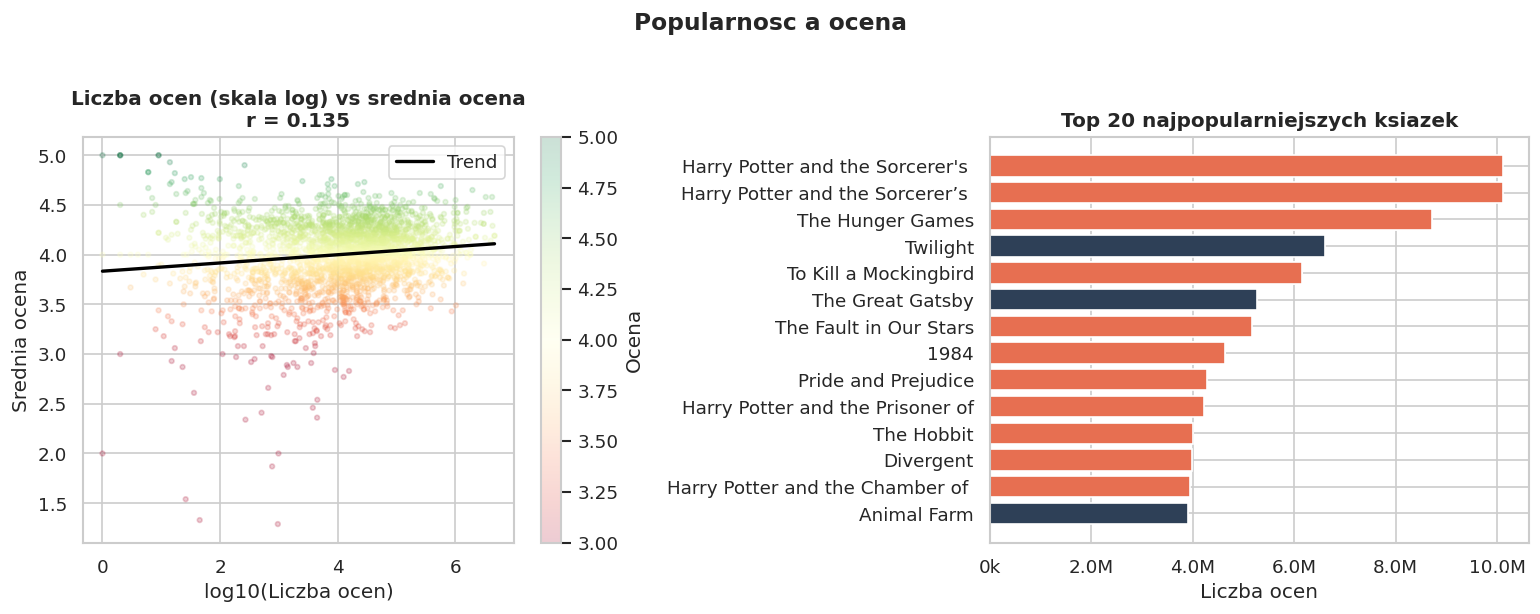

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
sc = axes[0].scatter(
    log_count, sample2[COL_RATING],
    alpha=0.2, s=8, c=sample2[COL_RATING], cmap='RdYlGn', vmin=3, vmax=5
)
plt.colorbar(sc, ax=axes[0], label='Ocena')

z2 = np.polyfit(log_count, sample2[COL_RATING], 1)
xs2 = np.linspace(log_count.min(), log_count.max(), 200)
axes[0].plot(xs2, np.poly1d(z2)(xs2), color='black', linewidth=2, label='Trend')

axes[0].set_title(f'Liczba ocen (skala log) vs srednia ocena\nr = {corr_pop:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('log10(Liczba ocen)')
axes[0].set_ylabel('Srednia ocena')
axes[0].legend()

# Top 20 najpopularniejszych
top_pop = df.nlargest(20, COL_COUNT)[[COL_TITLE, COL_RATING, COL_COUNT]].copy()
top_pop['krotki_tytul'] = top_pop[COL_TITLE].str[:32]

kolory_bar = [C3 if r >= 4.0 else C1 for r in top_pop[COL_RATING]]

axes[1].barh(
    top_pop['krotki_tytul'][::-1],
    top_pop[COL_COUNT][::-1],
    color=kolory_bar[::-1],
    edgecolor='white'
)
axes[1].set_title('Top 20 najpopularniejszych ksiazek', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Liczba ocen')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k')
)

plt.suptitle('Popularnosc a ocena', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Wniosek
Istnieje słaba pozytywna korelacja (r = 0.135) między zlogarytmowaną liczbą ocen a średnią oceną, co sugeruje, że popularniejsze książki (z większą liczbą ocen) mają tendencję do nieco wyższych średnich ocen, ale zależność nie jest silna. Wykres rozrzutu pokazuje, że punkty są szeroko rozproszone, szczególnie dla książek z mniejszą liczbą ocen, co świadczy o dużej zmienności. Bar chart przedstawiający Top 20 najpopularniejszych książek (z liczbą ocen w milionach) pokazuje, że choć są one bardzo popularne, ich średnie oceny (kolor słupków) obejmują zarówno bardzo wysoko oceniane tytuły, jak i te z ocenami około 4.0, co pokazuje, że popularność nie zawsze jest równoznaczna z najwyższą 'jakością' w kontekście średniej oceny.

---
## 7. Ranking — Top 10 i Bottom 10

In [22]:
# Tylko ksiazki z min. 1000 ocen — eliminuje tytuly z pojedynczymi recenzjami
MIN_OCEN = 1000

df_rank = df[df[COL_COUNT] >= MIN_OCEN].copy()
print(f'Ksiazek z min. {MIN_OCEN} ocenami: {len(df_rank):,}')

top10 = (
    df_rank.nlargest(10, COL_RATING)
    [[COL_TITLE, COL_AUTHOR, COL_RATING, COL_COUNT]]
    .reset_index(drop=True)
)

bot10 = (
    df_rank.nsmallest(10, COL_RATING)
    [[COL_TITLE, COL_AUTHOR, COL_RATING, COL_COUNT]]
    .reset_index(drop=True)
)

print('\nTOP 10')
print(top10.to_string(index=False))
print()
print('BOTTOM 10')
print(bot10.to_string(index=False))

Ksiazek z min. 1000 ocenami: 13,586

TOP 10
                                                book_title                author  average_rating  num_ratings
                                         Сад Гетсиманський        Ivan Bahrianyi            4.82         1579
                                   The Addiction Manifesto          Jerry Weaver            4.82         1160
Heaven Official's Blessing: Tian Guan Ci Fu (Novel) Vol. 6     Mò Xiāng Tóng Xiù            4.82         9453
                            The Complete Calvin and Hobbes        Bill Watterson            4.81        40335
                                                     Nutuk Mustafa Kemal Atatürk            4.81         5009
             All the Young Dudes - Volume Two: Years 5 - 7          MsKingBean89            4.81        17979
                                  Mark of the Lion Trilogy       Francine Rivers            4.78        13338
                                       All the Young Dudes          MsKingBe

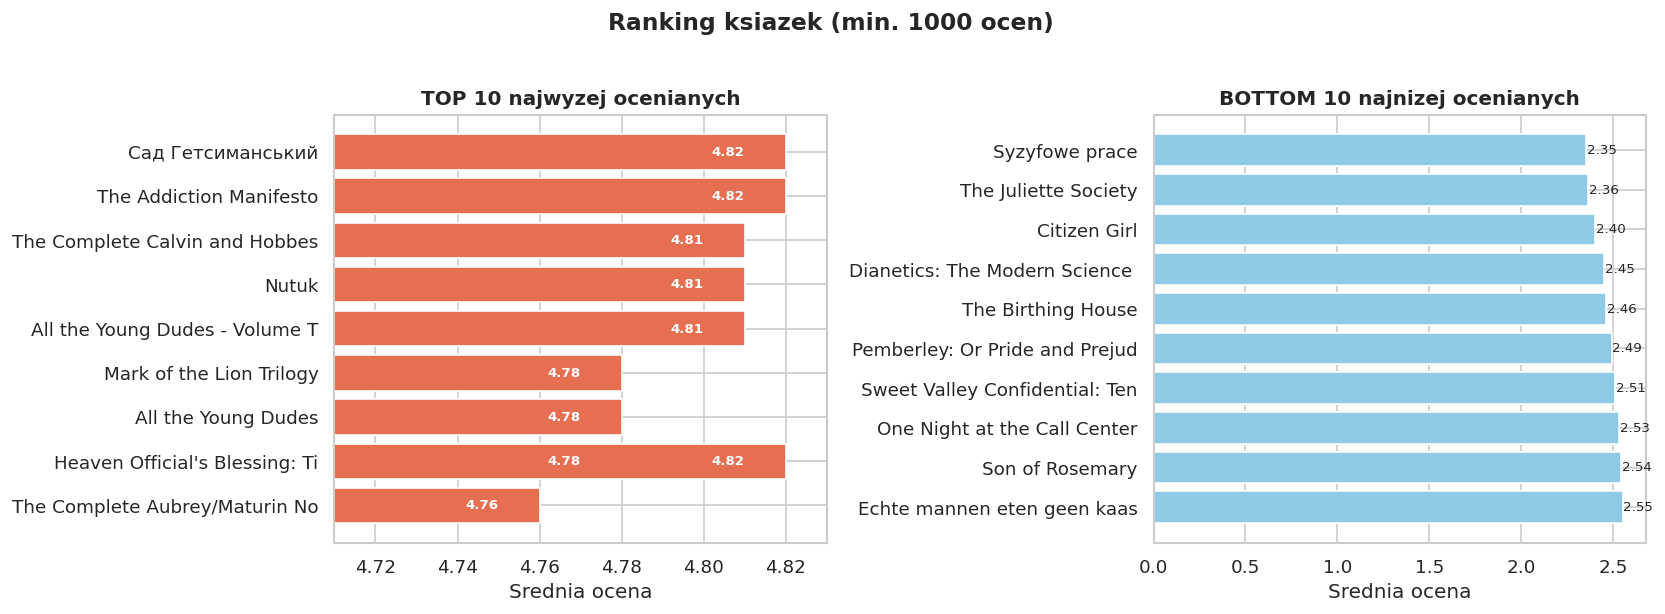

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10
axes[0].barh(
    top10[COL_TITLE].str[:30][::-1],
    top10[COL_RATING][::-1],
    color=C3, edgecolor='white'
)
for bar, val in zip(axes[0].patches, top10[COL_RATING][::-1]):
    axes[0].text(val - 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}', va='center', ha='right',
                 color='white', fontsize=8, fontweight='bold')
axes[0].set_title('TOP 10 najwyzej ocenianych', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Srednia ocena')
axes[0].set_xlim(top10[COL_RATING].min() - 0.05, top10[COL_RATING].max() + 0.01)

# Bottom 10
axes[1].barh(
    bot10[COL_TITLE].str[:30][::-1],
    bot10[COL_RATING][::-1],
    color=C4, edgecolor='white'
)
for bar, val in zip(axes[1].patches, bot10[COL_RATING][::-1]):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}', va='center', fontsize=8)
axes[1].set_title('BOTTOM 10 najnizej ocenianych', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Srednia ocena')

plt.suptitle(f'Ranking ksiazek (min. {MIN_OCEN} ocen)', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Wniosek
Ranking książek z minimum 1000 ocen eliminuje tytuły z pojedynczymi, potencjalnie niereprezentatywnymi recenzjami. Wykresy słupkowe jasno ilustrują ten ranking: najwyżej oceniane są często mniej znane tytuły lub te skierowane do specyficznego grona odbiorców (np. "Сад Гетсиманський", "The Addiction Manifesto"), co może sugerować, że niszowe książki lepiej spełniają oczekiwania swojej grupy docelowej. Z drugiej strony, najniżej oceniane książki to często te, które cieszyły się dużą popularnością, ale były też kontrowersyjne lub nie spełniały oczekiwań szerokiej publiczności (np. "Syzyfowe prace", "The Juliette Society").

---
## 8. Wnioski

### 1. Które gatunki mają najwyższe średnie oceny?
Gatunki takie jak Manga, Christian i Poetry wykazują najwyższe średnie oceny. Są to często nisze, gdzie czytelnicy mogą być bardziej zaangażowani i wybredni, co prowadzi do wyższego zadowolenia z wyselekcjonowanych tytułów. 'Unknown' również ma wysoką średnią, co wskazuje na potrzebę lepszej kategoryzacji lub specyfiki tych pozycji.

### 2. Czy liczba stron wpływa na ocenę?
Korelacja między liczbą stron a średnią oceną jest bardzo niska (r = 0.189). Oznacza to, że długość książki ma marginalny wpływ na jej odbiór. Chociaż najdłuższe książki (800+ stron) wykazują nieznacznie wyższe średnie, ogólny trend wskazuje, że nie jest to kluczowy czynnik wpływający na ocenę.

### 3. Czy popularność (liczba ocen) koreluje z jakością?
Stwierdzono słabą pozytywną korelację (r = 0.135) między zlogarytmowaną liczbą ocen a średnią oceną. Popularniejsze książki, mające więcej ocen, mogą mieć nieco wyższe średnie, ale zależność ta nie jest silna. Wśród najpopularniejszych tytułów znajdują się zarówno te bardzo wysoko oceniane, jak i te o bardziej umiarkowanych ocenach, co sugeruje, że popularność nie zawsze przekłada się na najwyższą 'jakość' w sensie średniej oceny.

### 4. Które książki są najwyżej i najniżej oceniane?
Analiza top 10 i bottom 10 (dla książek z minimum 1000 ocen) ujawniła, że najwyżej oceniane są często tytuły niszowe lub przeznaczone dla konkretnego grona odbiorców, co może świadczyć o głębszym zadowoleniu tej grupy. Z kolei najniżej oceniane książki to często te, które zdobyły dużą popularność, ale jednocześnie wzbudziły kontrowersje lub nie spełniły oczekiwań szerokiej publiczności.

---

**Ogolny wniosek:** Analiza danych z Goodreads pokazuje, że **gatunek jest najsilniejszym predyktorem oceny** spośród badanych zmiennych. Książki należące do specyficznych, niszowych gatunków, często otrzymują wyższe oceny, co może wynikać z dopasowania do oczekiwań wyselekcjonowanej grupy czytelników. Natomiast **liczba stron i popularność (mierzona liczbą ocen) mają jedynie marginalny wpływ statystyczny na średnią ocenę**. Wnioskuje się, że autentyczność i trafność w obrębie danego gatunku są bardziej cenione przez czytelników niż uniwersalna atrakcyjność czy objętość dzieła.